# Missing Value Imputation using Random Number Imputation

## Objective
Random Number Imputation is a missing value handling technique where missing values are replaced by randomly selected values from the existing (non-missing) values of the same feature.

This technique helps:
- Preserve the original distribution
- Maintain variance
- Avoid bias caused by mean or median imputation

In this notebook, we will:
1. Load a dataset
2. Understand missing values
3. Perform Random Number Imputation
4. Compare distributions before and after imputation
5. Visualize the results

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

## Load Dataset

For demonstration, we will use the Titanic dataset.

In [21]:
df = pd.read_csv("/content/Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Checking Missing Values

Before handling missing values, it is important to know:

- Which columns contain missing values?
- How many missing values are present?
- What percentage of data is missing?

In [22]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [23]:
missing_percentage = (df.isnull().mean()*100).round(2)

missing_percentage

,0
PassengerId,0.00
Survived,0.00
Pclass,0.00
Name,0.00
Sex,0.00
Age,19.87
SibSp,0.00
Parch,0.00
Ticket,0.00
Fare,0.00


## Selecting a Column

Random Number Imputation works well for numerical features.

We will use the **Age** column because it contains missing values.

In [24]:
df["Age"].head()

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


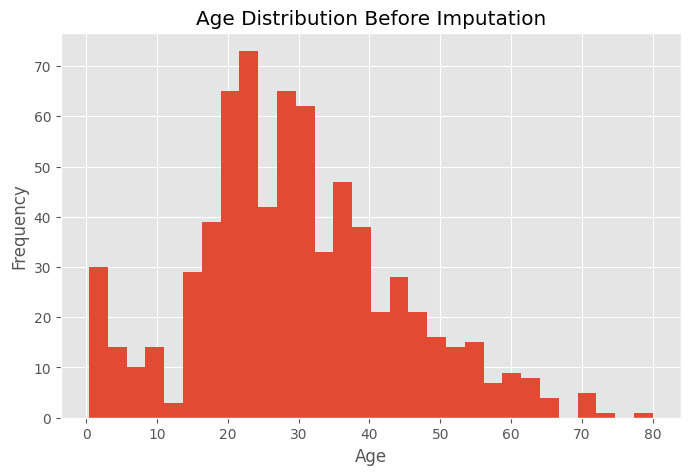

In [25]:
plt.figure(figsize=(8,5))

df["Age"].hist(bins=30)

plt.title("Age Distribution Before Imputation")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

# Random Number Imputation

### Working

Step 1:
Take all non-missing values.

Step 2:
Randomly select values from these existing observations.

Step 3:
Replace every missing value with one randomly selected value.

This preserves the data distribution better than Mean or Median Imputation.

In [26]:
def random_imputation(variable):

    random_sample = variable.dropna().sample(
        variable.isnull().sum(),
        random_state=42,
        replace=True
    )

    random_sample.index = variable[variable.isnull()].index

    return variable.fillna(random_sample)

In [27]:
df["Age_random"] = random_imputation(df["Age"])

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_random
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0


In [28]:
df[["Age","Age_random"]].isnull().sum()

,0
Age,177
Age_random,0


## Compare Original vs Random Imputed Distribution

The distributions should look very similar because missing values are replaced using existing observations.

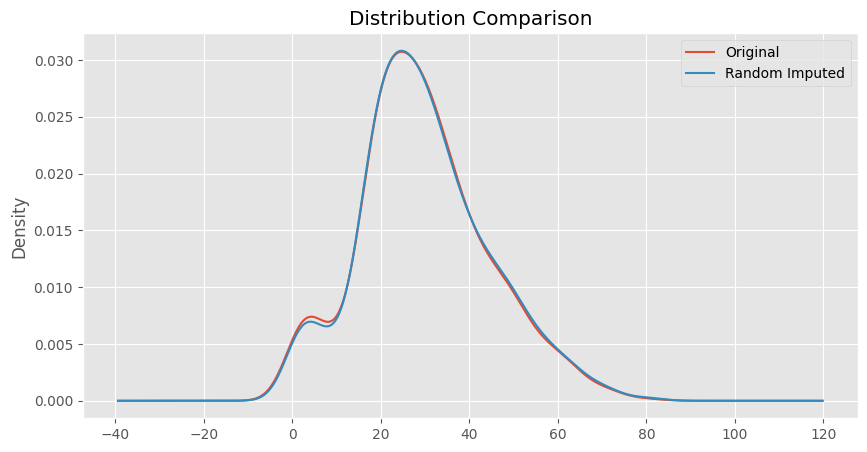

In [29]:
plt.figure(figsize=(10,5))

df["Age"].plot(kind="kde",label="Original")

df["Age_random"].plot(kind="kde",label="Random Imputed")

plt.legend()

plt.title("Distribution Comparison")

plt.show()

In [30]:
comparison = pd.DataFrame({
    "Original":df["Age"].describe(),
    "Random Imputed":df["Age_random"].describe()
})

comparison

,Original,Random Imputed
count,714.000000,891.000000
mean,29.699118,29.999540
std,14.526497,14.633756
min,0.420000,0.420000
25%,20.125000,21.000000
50%,28.000000,28.000000
75%,38.000000,39.000000
max,80.000000,80.000000


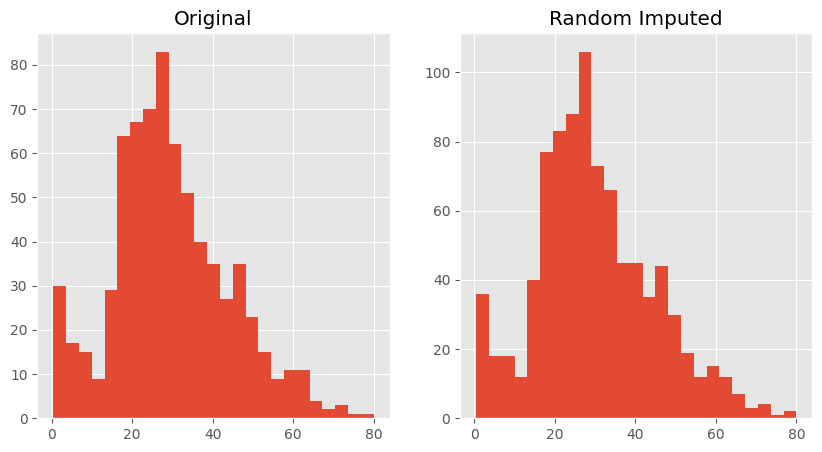

In [31]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

df["Age"].hist(bins=25)

plt.title("Original")

plt.subplot(1,2,2)

df["Age_random"].hist(bins=25)

plt.title("Random Imputed")

plt.show()

# Advantages

✔ Preserves the original distribution

✔ Preserves variance

✔ Better than Mean Imputation in many cases

✔ Easy to implement

✔ Useful when missing values are MCAR (Missing Completely At Random)

# Disadvantages

✖ Results change if random_state is not fixed

✖ May introduce noise

✖ Not suitable for large percentages of missing values

✖ Different runs can produce different outputs

# Conclusion

Random Number Imputation replaces missing values by randomly selecting existing values from the same feature.

Compared to Mean or Median Imputation:

- Better preserves variance
- Maintains the original distribution
- Reduces distortion in machine learning models

However, since the values are randomly chosen, fixing a `random_state` is recommended for reproducibility.